In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

print("================================================================")
print("MEMULAI VALIDASI MODEL: K-MEANS VS AGGLOMERATIVE CLUSTERING")
print("================================================================")

# 1. LOAD DATA MASTER DEMAND & SUPPLY
df_demand = pd.read_csv("master_demand_matrix_final.csv")
df_supply = pd.read_csv("master_supply_matrix_updated_with_revisions.csv")

# Tambalan data kosong spasial untuk area daratan
df_supply['Supply_Avg_Port_Dist_KM'] = df_supply['Supply_Avg_Port_Dist_KM'].fillna(0)

# 2. GRAND JOIN
df_total = pd.merge(df_demand, df_supply, on='DPP', how='inner')

# 3. SELEKSI FITUR LINTAS DIMENSI
fitur_analisis = [
    'Search_Volume_Score', 'TikTok_Total_Engagement', 'GoogleMaps_Avg_Rating',
    'Supply_Total_Hotels', 'Supply_Avg_Hotel_Price', 'Supply_Avg_Airport_Dist_KM', 
    'Supply_Avg_Port_Dist_KM', 'Flight_Frequency'
]

# 4. TRANSFORMAI MIN-MAX SCALING
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_total[fitur_analisis])

# 5. LOOPING ITERASI MENCARI K TERBAIK
rekaman_skor = []
max_k_terizin = len(df_total)  # Bernilai 10 sesuai jumlah baris DPP

# Melakukan perulangan dari K=2 hingga K=9 (Batas maksimal komputasi n-1)
for k in range(2, max_k_terizin):
    hasil_loop = {'Nilai_K': k}
    
    # --- PENGUJIAN METODE 1: K-MEANS ---
    model_km = KMeans(n_clusters=k, random_state=42, n_init=10)
    label_km = model_km.fit_predict(X_scaled)
    # Hitung skor siluet (Makin mendekati 1 makin tajam pengelompokannya)
    hasil_loop['Skor_K-Means'] = silhouette_score(X_scaled, label_km)
    
    # --- PENGUJIAN METODE 2: AGGLOMERATIVE HIERARCHICAL ---
    model_agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    label_agg = model_agg.fit_predict(X_scaled)
    hasil_loop['Skor_Agglomerative'] = silhouette_score(X_scaled, label_agg)
    
    rekaman_skor.append(hasil_loop)

# 6. RINGKASAN HASIL EVALUASI MODEL
df_evaluasi = pd.DataFrame(rekaman_skor)
print("\n=== TABEL PERBANDINGAN SILHOUETTE SCORE ===")
print(df_evaluasi.round(3).to_string(index=False))

# Mencari baris dengan performa model tertinggi
terbaik_km = df_evaluasi.loc[df_evaluasi['Skor_K-Means'].idxmax()]
terbaik_agg = df_evaluasi.loc[df_evaluasi['Skor_Agglomerative'].idxmax()]

print("\n================================================================")
print("KESIMPULAN OPTIMASI MODEL UNTUK PPT:")
print("================================================================")
print(f"📌 Skor K-Means Tertinggi       : K = {int(terbaik_km['Nilai_K'])} (Skor: {terbaik_km['Skor_K-Means']:.3f})")
print(f"📌 Skor Agglomerative Tertinggi : K = {int(terbaik_agg['Nilai_K'])} (Skor: {terbaik_agg['Skor_Agglomerative']:.3f})")
print("================================================================")

MEMULAI VALIDASI MODEL: K-MEANS VS AGGLOMERATIVE CLUSTERING

=== TABEL PERBANDINGAN SILHOUETTE SCORE ===
 Nilai_K  Skor_K-Means  Skor_Agglomerative
       2         0.200               0.196
       3         0.223               0.223
       4         0.227               0.214
       5         0.221               0.201
       6         0.174               0.170
       7         0.124               0.124
       8         0.104               0.104
       9         0.042               0.042

KESIMPULAN OPTIMASI MODEL UNTUK PPT:
📌 Skor K-Means Tertinggi       : K = 4 (Skor: 0.227)
📌 Skor Agglomerative Tertinggi : K = 3 (Skor: 0.223)


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

print("================================================================")
print("MEMULAI EKSEKUSI 3 METODE CLUSTERING (K=4) UNTUK 10 DPP")
print("================================================================")

# 1. LOAD DATA MASTER DEMAND & SUPPLY
df_demand = pd.read_csv("master_demand_matrix_final.csv")
df_supply = pd.read_csv("master_supply_matrix_final_1.csv")

# Tambalan data kosong spasial untuk area daratan
df_supply['Supply_Avg_Port_Dist_KM'] = df_supply['Supply_Avg_Port_Dist_KM'].fillna(0)

# 2. GRAND JOIN (SINKRONISASI DATA)
df_total = pd.merge(df_demand, df_supply, on='DPP', how='inner')

# 3. SELEKSI FITUR LINTAS DIMENSI
fitur_analisis = [
    'Search_Volume_Score', 'TikTok_Total_Engagement', 'GoogleMaps_Avg_Rating',
    'Supply_Total_Hotels', 'Supply_Avg_Hotel_Price', 'Supply_Avg_Airport_Dist_KM', 
    'Supply_Avg_Port_Dist_KM', 'Flight_Frequency'
]

# 4. PREPROCESSING: NORMALISASI MIN-MAX
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_total[fitur_analisis])

# 5. EKSEKUSI KLASTERISASI DENGAN 3 METODE (K=4)
target_k = 4

# --- Metode 1: K-Means ---
model_km = KMeans(n_clusters=target_k, random_state=42, n_init=10)
df_total['Cluster_KMeans'] = model_km.fit_predict(X_scaled)

# --- Metode 2: Agglomerative Hierarchical ---
model_agg = AgglomerativeClustering(n_clusters=target_k, linkage='ward')
df_total['Cluster_Hierarchical'] = model_agg.fit_predict(X_scaled)

# --- Metode 3: Gaussian Mixture Models (GMM) ---
model_gmm = GaussianMixture(n_components=target_k, random_state=42)
model_gmm.fit(X_scaled)
df_total['Cluster_GMM'] = model_gmm.predict(X_scaled)

# 6. MENAMPILKAN TABEL KOMPARASI HASIL KLASTER
print("\n=== TABEL PERBANDINGAN HASIL PENGELOMPOKAN 10 DPP ===")
kolom_output = ['DPP', 'Cluster_KMeans', 'Cluster_Hierarchical', 'Cluster_GMM']
df_perbandingan = df_total[kolom_output].sort_values(by='Cluster_KMeans')
print(df_perbandingan.to_string(index=False))

# 7. SIMPAN HASIL KOMPARASI UNTUK BAHAN ANALISIS GAP
nama_file_komparasi = "master_clustering_comparison.csv"
df_total.to_csv(nama_file_komparasi, index=False)
print(f"\n✅ Sukses! File perbandingan disimpan ke '{nama_file_komparasi}'")
print("================================================================")

MEMULAI EKSEKUSI 3 METODE CLUSTERING (K=4) UNTUK 10 DPP

=== TABEL PERBANDINGAN HASIL PENGELOMPOKAN 10 DPP ===
             DPP  Cluster_KMeans  Cluster_Hierarchical  Cluster_GMM
Tanjung Kelayang               0                     2            3
       Borobudur               1                     3            1
       Mandalika               1                     3            1
     Labuan Bajo               1                     0            0
        Likupang               1                     0            1
      Danau Toba               2                     1            2
      Raja Ampat               2                     1            2
           Bromo               2                     1            2
         Morotai               3                     0            1
        Wakatobi               3                     0            1

✅ Sukses! File perbandingan disimpan ke 'master_clustering_comparison.csv'


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import warnings

# Menghilangkan peringatan setting n_init
warnings.filterwarnings('ignore')

# 1. LOAD & JOIN DATA
df_demand = pd.read_csv("master_demand_matrix_final.csv")
df_supply = pd.read_csv("master_supply_matrix_final_1.csv")
df_supply['Supply_Avg_Port_Dist_KM'] = df_supply['Supply_Avg_Port_Dist_KM'].fillna(0)
df_total = pd.merge(df_demand, df_supply, on='DPP', how='inner')

# 2. PREPROCESSING
fitur = [
    'Search_Volume_Score', 'TikTok_Total_Engagement', 'GoogleMaps_Avg_Rating',
    'Supply_Total_Hotels', 'Supply_Avg_Hotel_Price', 'Supply_Avg_Airport_Dist_KM', 
    'Supply_Avg_Port_Dist_KM', 'Flight_Frequency'
]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_total[fitur])

# 3. PROSES ITERASI K=2 SAMPAI K=9
summary_results = []

print("Sedang menghitung performa model...")

for k in range(2, 10): # Range 2 sampai 9
    # Inisialisasi baris hasil
    res = {'K': k}
    
    # --- K-Means ---
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    label_km = km.fit_predict(X_scaled)
    res['K-Means'] = silhouette_score(X_scaled, label_km)
    
    # --- Agglomerative (Hierarchical) ---
    agg = AgglomerativeClustering(n_clusters=k)
    label_agg = agg.fit_predict(X_scaled)
    res['Hierarchical'] = silhouette_score(X_scaled, label_agg)
    
    # --- GMM (Gaussian Mixture) ---
    gmm = GaussianMixture(n_components=k, random_state=42)
    label_gmm = gmm.fit_predict(X_scaled)
    res['GMM'] = silhouette_score(X_scaled, label_gmm)
    
    summary_results.append(res)

# 4. TAMPILKAN HASIL EVALUASI
df_eval = pd.DataFrame(summary_results)
print("\n=== PERBANDINGAN SILHOUETTE SCORE ===")
print("(Nilai semakin tinggi = Klaster semakin bagus)")
print("-" * 50)
print(df_eval.round(4).to_string(index=False))
print("-" * 50)

# Simpan ke CSV untuk bahan catatan di Docs
df_eval.to_csv("evaluasi_k_clustering.csv", index=False)
print("\n✅ Hasil evaluasi disimpan ke 'evaluasi_k_clustering.csv'")

Sedang menghitung performa model...

=== PERBANDINGAN SILHOUETTE SCORE ===
(Nilai semakin tinggi = Klaster semakin bagus)
--------------------------------------------------
 K  K-Means  Hierarchical    GMM
 2   0.2004        0.1958 0.2004
 3   0.2235        0.2235 0.1024
 4   0.2272        0.2136 0.1464
 5   0.2211        0.2006 0.2211
 6   0.1741        0.1701 0.1741
 7   0.1244        0.1244 0.1092
 8   0.1043        0.1043 0.0889
 9   0.0416        0.0416 0.0416
--------------------------------------------------

✅ Hasil evaluasi disimpan ke 'evaluasi_k_clustering.csv'


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import distances_from_masks, pairwise_distances # Menggunakan fungsi jarak bawaan sklearn
import warnings

warnings.filterwarnings('ignore')

# ==================================================================
# KLASTER CUSTOM: PURE PYTHON K-MEDOIDS (PAM ALGORITHM)
# ==================================================================
class PurePythonKMedoids:
    def __init__(self, n_clusters=3, max_iter=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        
    def fit_predict(self, X):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        
        # 1. Inisialisasi medoids secara acak dari objek riil yang ada
        medoids = np.random.choice(n_samples, self.n_clusters, replace=False)
        
        # Hitung matriks jarak matriks antar seluruh objek (Euclidean)
        D = pairwise_distances(X, metric='euclidean')
        
        for _ in range(self.max_iter):
            # 2. Asosiasikan setiap objek ke medoid terdekat
            labels = np.argmin(D[:, medoids], axis=1)
            new_medoids = np.copy(medoids)
            
            # 3. Update Medoid: Cari objek di dalam klaster yang meminimalkan total jarak
            for k in range(self.n_clusters):
                cluster_idx = np.where(labels == k)[0]
                if len(cluster_idx) == 0:
                    continue
                # Ambil sub-matriks jarak untuk anggota klaster ini
                sub_D = D[cluster_idx, :][:, cluster_idx]
                dist_sums = sub_D.sum(axis=1)
                # Objek riil dengan total jarak terkecil resmi jadi medoid baru
                new_medoids[k] = cluster_idx[np.argmin(dist_sums)]
                
            # Jika pusat medoid sudah tidak berubah, komputasi selesai
            if np.array_equal(medoids, new_medoids):
                break
            medoids = new_medoids
            
        return np.argmin(D[:, medoids], axis=1)

# ==================================================================
# MAIN PROCESS: ITERASI K=2 S/D K=9
# ==================================================================
print("==================================================================")
print("MEMULAI EVALUASI ITERASI K=2 S/D K=9 DENGAN LOGIKA PARALEL PURE PYTHON")
print("==================================================================")

# 1. LOAD & JOIN DATA
df_demand = pd.read_csv("master_demand_matrix_final.csv")
df_supply = pd.read_csv("master_supply_matrix_final_1.csv")
df_supply['Supply_Avg_Port_Dist_KM'] = df_supply['Supply_Avg_Port_Dist_KM'].fillna(0)
df_total = pd.merge(df_demand, df_supply, on='DPP', how='inner')

# 2. PREPROCESSING
fitur = [
    'Search_Volume_Score', 'TikTok_Total_Engagement', 'GoogleMaps_Avg_Rating',
    'Supply_Total_Hotels', 'Supply_Avg_Hotel_Price', 'Supply_Avg_Airport_Dist_KM', 
    'Supply_Avg_Port_Dist_KM', 'Flight_Frequency'
]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_total[fitur])

# 3. PROSES ITERASI
summary_results = []

for k in range(2, 10):
    res = {'K': k}
    
    # --- Metode 1: K-Means (Centroid-Based) ---
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    label_km = km.fit_predict(X_scaled)
    res['K-Means'] = silhouette_score(X_scaled, label_km)
    
    # --- Metode 2: Agglomerative Hierarchical (Connectivity-Based) ---
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    label_agg = agg.fit_predict(X_scaled)
    res['Hierarchical'] = silhouette_score(X_scaled, label_agg)
    
    # --- Metode 3: K-Medoids / PAM (Custom Pure Python - Bebas Error C-Extension) ---
    kmed = PurePythonKMedoids(n_clusters=k, random_state=42)
    label_kmed = kmed.fit_predict(X_scaled)
    res['K-Medoids'] = silhouette_score(X_scaled, label_kmed)
    
    summary_results.append(res)

# 4. TAMPILKAN HASIL EVALUASI AKHIR
df_eval = pd.DataFrame(summary_results)
print("\n=== PERBANDINGAN SILHOUETTE SCORE AKHIR ===")
print("(Nilai tertinggi menunjukkan struktur pembagian kelompok terbaik)")
print("-" * 65)
print(df_eval.round(4).to_string(index=False))
print("-" * 65)

# Simpan hasil evaluasi ke CSV demi kebutuhan Docs tim
df_eval.to_csv("evaluasi_k_clustering.csv", index=False)
print("\n✅ Langkah aman berhasil! Hasil evaluasi malam ini disimpan ke 'evaluasi_k_clustering.csv'")
print("==================================================================")

ImportError: cannot import name 'distances_from_masks' from 'sklearn.metrics.pairwise' (c:\Users\User\Desktop\KULIAH\SEMESTER 6\SDC\kemenpar\.venv\Lib\site-packages\sklearn\metrics\pairwise.py)

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import pairwise_distances # KOREKSI: Hanya mengimpor fungsi yang benar-benar digunakan
import warnings

warnings.filterwarnings('ignore')

# ==================================================================
# KLASTER CUSTOM: PURE PYTHON K-MEDOIDS (PAM ALGORITHM)
# ==================================================================
class PurePythonKMedoids:
    def __init__(self, n_clusters=3, max_iter=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        
    def fit_predict(self, X):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        
        # 1. Inisialisasi medoids secara acak dari objek riil yang ada
        medoids = np.random.choice(n_samples, self.n_clusters, replace=False)
        
        # Hitung matriks jarak antar seluruh objek (Euclidean)
        D = pairwise_distances(X, metric='euclidean')
        
        for _ in range(self.max_iter):
            # 2. Asosiasikan setiap objek ke medoid terdekat
            labels = np.argmin(D[:, medoids], axis=1)
            new_medoids = np.copy(medoids)
            
            # 3. Update Medoid: Cari objek di dalam klaster yang meminimalkan total jarak
            for k in range(self.n_clusters):
                cluster_idx = np.where(labels == k)[0]
                if len(cluster_idx) == 0:
                    continue
                # Ambil sub-matriks jarak untuk anggota klaster ini
                sub_D = D[cluster_idx, :][:, cluster_idx]
                dist_sums = sub_D.sum(axis=1)
                # Objek riil dengan total jarak terkecil resmi jadi medoid baru
                new_medoids[k] = cluster_idx[np.argmin(dist_sums)]
                
            # Jika pusat medoid sudah tidak berubah, komputasi selesai
            if np.array_equal(medoids, new_medoids):
                break
            medoids = new_medoids
            
        return np.argmin(D[:, medoids], axis=1)

# ==================================================================
# MAIN PROCESS: ITERASI K=2 S/D K=9
# ==================================================================
print("==================================================================")
print("MEMULAI EVALUASI ITERASI K=2 S/D K=9 DENGAN LOGIKA PARALEL PURE PYTHON")
print("==================================================================")

# 1. LOAD & JOIN DATA
df_demand = pd.read_csv("master_demand_matrix_final.csv")
df_supply = pd.read_csv("master_supply_matrix_final_1.csv")
df_supply['Supply_Avg_Port_Dist_KM'] = df_supply['Supply_Avg_Port_Dist_KM'].fillna(0)
df_total = pd.merge(df_demand, df_supply, on='DPP', how='inner')

# 2. PREPROCESSING
fitur = [
    'Search_Volume_Score', 'TikTok_Total_Engagement', 'GoogleMaps_Avg_Rating',
    'Supply_Total_Hotels', 'Supply_Avg_Hotel_Price', 'Supply_Avg_Airport_Dist_KM', 
    'Supply_Avg_Port_Dist_KM', 'Flight_Frequency'
]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_total[fitur])

# 3. PROSES ITERASI
summary_results = []

for k in range(2, 10):
    res = {'K': k}
    
    # --- Metode 1: K-Means (Centroid-Based) ---
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    label_km = km.fit_predict(X_scaled)
    res['K-Means'] = silhouette_score(X_scaled, label_km)
    
    # --- Metode 2: Agglomerative Hierarchical (Connectivity-Based) ---
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    label_agg = agg.fit_predict(X_scaled)
    res['Hierarchical'] = silhouette_score(X_scaled, label_agg)
    
    # --- Metode 3: K-Medoids / PAM (Custom Pure Python - Bebas Error C-Extension) ---
    kmed = PurePythonKMedoids(n_clusters=k, random_state=42)
    label_kmed = kmed.fit_predict(X_scaled)
    res['K-Medoids'] = silhouette_score(X_scaled, label_kmed)
    
    summary_results.append(res)

# 4. TAMPILKAN HASIL EVALUASI AKHIR
df_eval = pd.DataFrame(summary_results)
print("\n=== PERBANDINGAN SILHOUETTE SCORE AKHIR ===")
print("(Nilai tertinggi menunjukkan struktur pembagian kelompok terbaik)")
print("-" * 65)
print(df_eval.round(4).to_string(index=False))
print("-" * 65)

# Simpan hasil evaluasi ke CSV demi kebutuhan Docs tim
df_eval.to_csv("evaluasi_k_clustering.csv", index=False)
print("\n✅ Langkah aman berhasil! Hasil evaluasi malam ini disimpan ke 'evaluasi_k_clustering.csv'")
print("==================================================================")

MEMULAI EVALUASI ITERASI K=2 S/D K=9 DENGAN LOGIKA PARALEL PURE PYTHON

=== PERBANDINGAN SILHOUETTE SCORE AKHIR ===
(Nilai tertinggi menunjukkan struktur pembagian kelompok terbaik)
-----------------------------------------------------------------
 K  K-Means  Hierarchical  K-Medoids
 2   0.2004        0.1958     0.2828
 3   0.2235        0.2235     0.2123
 4   0.2272        0.2136     0.0469
 5   0.2211        0.2006    -0.0210
 6   0.1741        0.1701    -0.0061
 7   0.1244        0.1244     0.0588
 8   0.1043        0.1043     0.0105
 9   0.0416        0.0416     0.0041
-----------------------------------------------------------------

✅ Langkah aman berhasil! Hasil evaluasi malam ini disimpan ke 'evaluasi_k_clustering.csv'


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

print("==================================================================")
print("MEMULAI FINALISASI MODEL K-MEANS (K=4) & DEMAND-SUPPLY GAP ANALYSIS")
print("==================================================================")

# 1. LOAD DATA MASTER DEMAND & SUPPLY
df_demand = pd.read_csv("master_demand_matrix_final.csv")
df_supply = pd.read_csv("master_supply_matrix_final_1.csv")

# Tambalan data kosong spasial untuk area daratan agar aman di model
df_supply['Supply_Avg_Port_Dist_KM'] = df_supply['Supply_Avg_Port_Dist_KM'].fillna(0)

# 2. GRAND JOIN: Satukan Sisi Demand & Supply
df_final = pd.merge(df_demand, df_supply, on='DPP', how='inner')

# 3. SELEKSI FITUR PEMODELAN
fitur_demand = ['Search_Volume_Score', 'TikTok_Total_Engagement', 'GoogleMaps_Avg_Rating']
fitur_supply = [
    'Supply_Total_Hotels', 'Supply_Avg_Hotel_Price', 'Supply_Avg_Airport_Dist_KM', 
    'Supply_Avg_Port_Dist_KM', 'Flight_Frequency'
]
semua_fitur = fitur_demand + fitur_supply

# 4. NORMALISASI MIN-MAX (Skala 0 - 1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_final[semua_fitur])
df_scaled = pd.DataFrame(X_scaled, columns=semua_fitur)

# REKAYASA SPASIAL: Balik nilai fitur jarak (Inversi) agar searah dengan indikator positif
df_scaled['Supply_Avg_Airport_Dist_KM'] = 1 - df_scaled['Supply_Avg_Airport_Dist_KM']
df_scaled['Supply_Avg_Port_Dist_KM'] = 1 - df_scaled['Supply_Avg_Port_Dist_KM']

# 5. REKAYASA INDEKS: Menghitung Nilai Komposit Komparatif (Skala 0 - 100)
df_final['Demand_Index'] = df_scaled[fitur_demand].mean(axis=1) * 100
df_final['Supply_Index'] = df_scaled[fitur_supply].mean(axis=1) * 100

# 6. DEMAND-SUPPLY GAP ANALYSIS: Menghitung Kesenjangan
# Rumus: Demand Index - Supply Index
df_final['Gap_Score'] = df_final['Demand_Index'] - df_final['Supply_Index']

# 7. EKSEKUSI MODEL K-MEANS FINAL (K=4)
# Menggunakan data skala 0-1 agar bobot variabel seimbang dan adil
model_kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['Cluster_Label'] = model_kmeans_final.fit_predict(X_scaled)

# 8. INVESTMENT OPPORTUNITY MAPPING (Pelabelan Persona Bisnis Berbasis Profil Klaster)
# Pemetaan kuadran strategis untuk bahan paparan ke Kemenpar / Investor
pemetaan_kuadran = {
    0: "High Intent, Infrastructure Gap",
    1: "Premium & Infrastructure Ready",
    2: "Social Media Magnets",
    3: "Early-Stage Frontier"
}
df_final['Investment_Quadrant'] = df_final['Cluster_Label'].map(pemetaan_kuadran)

# 9. TAMPILKAN HASIL AKHIR PENILAIAN STRATEGIS
print("\n=== MATRIKS STRATEGIS PELUANG INVESTASI (10 DPP INDONESIA) ===")
kolom_tampil = ['DPP', 'Cluster_Label', 'Demand_Index', 'Supply_Index', 'Gap_Score', 'Investment_Quadrant']
print(df_final[kolom_tampil].sort_values(by='Cluster_Label').to_string(index=False))

# 10. SIMPAN SEBAGAI MASTER DATASET DASHBOARD FINAL
nama_output_final = "final_dashboard_dataset.csv"
df_final.to_csv(nama_output_final, index=False)
print(f"\n✅ INTEGRASI SELESAI! File '{nama_output_final}' siap dimasukkan ke Tableau.")
print("==================================================================")

MEMULAI FINALISASI MODEL K-MEANS (K=4) & DEMAND-SUPPLY GAP ANALYSIS

=== MATRIKS STRATEGIS PELUANG INVESTASI (10 DPP INDONESIA) ===
             DPP  Cluster_Label  Demand_Index  Supply_Index  Gap_Score             Investment_Quadrant
Tanjung Kelayang              0     54.761905     14.233477  40.528428 High Intent, Infrastructure Gap
       Borobudur              1     50.687906     67.950960 -17.263054  Premium & Infrastructure Ready
       Mandalika              1     29.141189     63.107025 -33.965836  Premium & Infrastructure Ready
     Labuan Bajo              1     62.166693     78.278236 -16.111543  Premium & Infrastructure Ready
        Likupang              1     50.067069     63.050209 -12.983141  Premium & Infrastructure Ready
      Danau Toba              2     35.992280     54.316020 -18.323740            Social Media Magnets
      Raja Ampat              2     66.666667     56.140757  10.525909            Social Media Magnets
           Bromo              2     61.81313

In [8]:
import pandas as pd
import numpy as np

print("Mengomputasi Kategorisasi Demand-Supply Gap Analysis...")

# 1. Load dataset final hasil clustering kemarin
df_final = pd.read_csv("final_dashboard_dataset.csv")

# 2. Membuat logika kategorisasi berbasis nilai Gap Score
# Gap > 0 artinya Under-Supply, Gap <= 0 artinya Over-Supply
df_final['Gap_Status'] = np.where(df_final['Gap_Score'] > 0, 'Under-Supply (Kekurangan Fasilitas)', 'Over-Supply (Kelebihan Kapasitas)')

# 3. Urutkan dari nilai Gap terbesar (Paling potensial untuk investasi)
df_gap_analysis = df_final[['DPP', 'Demand_Index', 'Supply_Index', 'Gap_Score', 'Gap_Status']].sort_values(by='Gap_Score', ascending=False)

print("\n=== HASIL EKSEKUSI GAP ANALYSIS ===")
print(df_gap_analysis.to_string(index=False))

# 4. Simpan hasil spesifik ini untuk lampiran Docs kelompok
df_gap_analysis.to_csv("demand_supply_gap_report.csv", index=False)
print("\n✅ File laporan gap 'demand_supply_gap_report.csv' berhasil diamankan!")

Mengomputasi Kategorisasi Demand-Supply Gap Analysis...

=== HASIL EKSEKUSI GAP ANALYSIS ===
             DPP  Demand_Index  Supply_Index  Gap_Score                          Gap_Status
Tanjung Kelayang     54.761905     14.233477  40.528428 Under-Supply (Kekurangan Fasilitas)
      Raja Ampat     66.666667     56.140757  10.525909 Under-Supply (Kekurangan Fasilitas)
        Wakatobi     49.962955     40.988075   8.974880 Under-Supply (Kekurangan Fasilitas)
           Bromo     61.813136     58.136442   3.676694 Under-Supply (Kekurangan Fasilitas)
        Likupang     50.067069     63.050209 -12.983141   Over-Supply (Kelebihan Kapasitas)
     Labuan Bajo     62.166693     78.278236 -16.111543   Over-Supply (Kelebihan Kapasitas)
       Borobudur     50.687906     67.950960 -17.263054   Over-Supply (Kelebihan Kapasitas)
         Morotai     16.879583     34.884894 -18.005311   Over-Supply (Kelebihan Kapasitas)
      Danau Toba     35.992280     54.316020 -18.323740   Over-Supply (Kelebiha

In [9]:
import pandas as pd

print("Memulai Proses Profiling Karakteristik 4 Klaster...")

# 1. Load dataset final yang sudah memiliki kolom Cluster_Label dan Gap_Score
df_final = pd.read_csv("final_dashboard_dataset.csv")

# 2. Agregasi data: Hitung rata-rata fitur asli berdasarkan Cluster_Label
cluster_profile = df_final.groupby('Cluster_Label').agg(
    Jumlah_DPP=('DPP', 'count'),
    Rata_Demand_Index=('Demand_Index', 'mean'),
    Rata_Supply_Index=('Supply_Index', 'mean'),
    Rata_Gap_Score=('Gap_Score', 'mean'),
    Rata_Hotel=('Supply_Total_Hotels', 'mean'),
    Rata_Harga_Hotel=('Supply_Avg_Hotel_Price', 'mean'),
    Rata_Penerbangan=('Flight_Frequency', 'mean')
).reset_index()

print("\n=== PROFIL RATA-RATA KARAKTERISTIK KLASTER ===")
print(cluster_profile.round(2).to_string(index=False))

print("\n=== ANGGOTA MASING-MASING KLASTER ===")
for cluster in sorted(df_final['Cluster_Label'].unique()):
    anggota = df_final[df_final['Cluster_Label'] == cluster]['DPP'].tolist()
    print(f"Klaster {cluster} : {anggota}")

Memulai Proses Profiling Karakteristik 4 Klaster...

=== PROFIL RATA-RATA KARAKTERISTIK KLASTER ===
 Cluster_Label  Jumlah_DPP  Rata_Demand_Index  Rata_Supply_Index  Rata_Gap_Score  Rata_Hotel  Rata_Harga_Hotel  Rata_Penerbangan
             0           1              54.76              14.23           40.53      276.00         478846.22              7.00
             1           4              48.02              68.10          -20.08      200.50        1358450.85             46.75
             2           3              54.82              56.20           -1.37      374.67        1026093.40             10.33
             3           2              33.42              37.94           -4.52       28.50        1144366.44              0.00

=== ANGGOTA MASING-MASING KLASTER ===
Klaster 0 : ['Tanjung Kelayang']
Klaster 1 : ['Borobudur', 'Labuan Bajo', 'Likupang', 'Mandalika']
Klaster 2 : ['Bromo', 'Danau Toba', 'Raja Ampat']
Klaster 3 : ['Morotai', 'Wakatobi']


Generating High-Resolution Cluster Visualization...


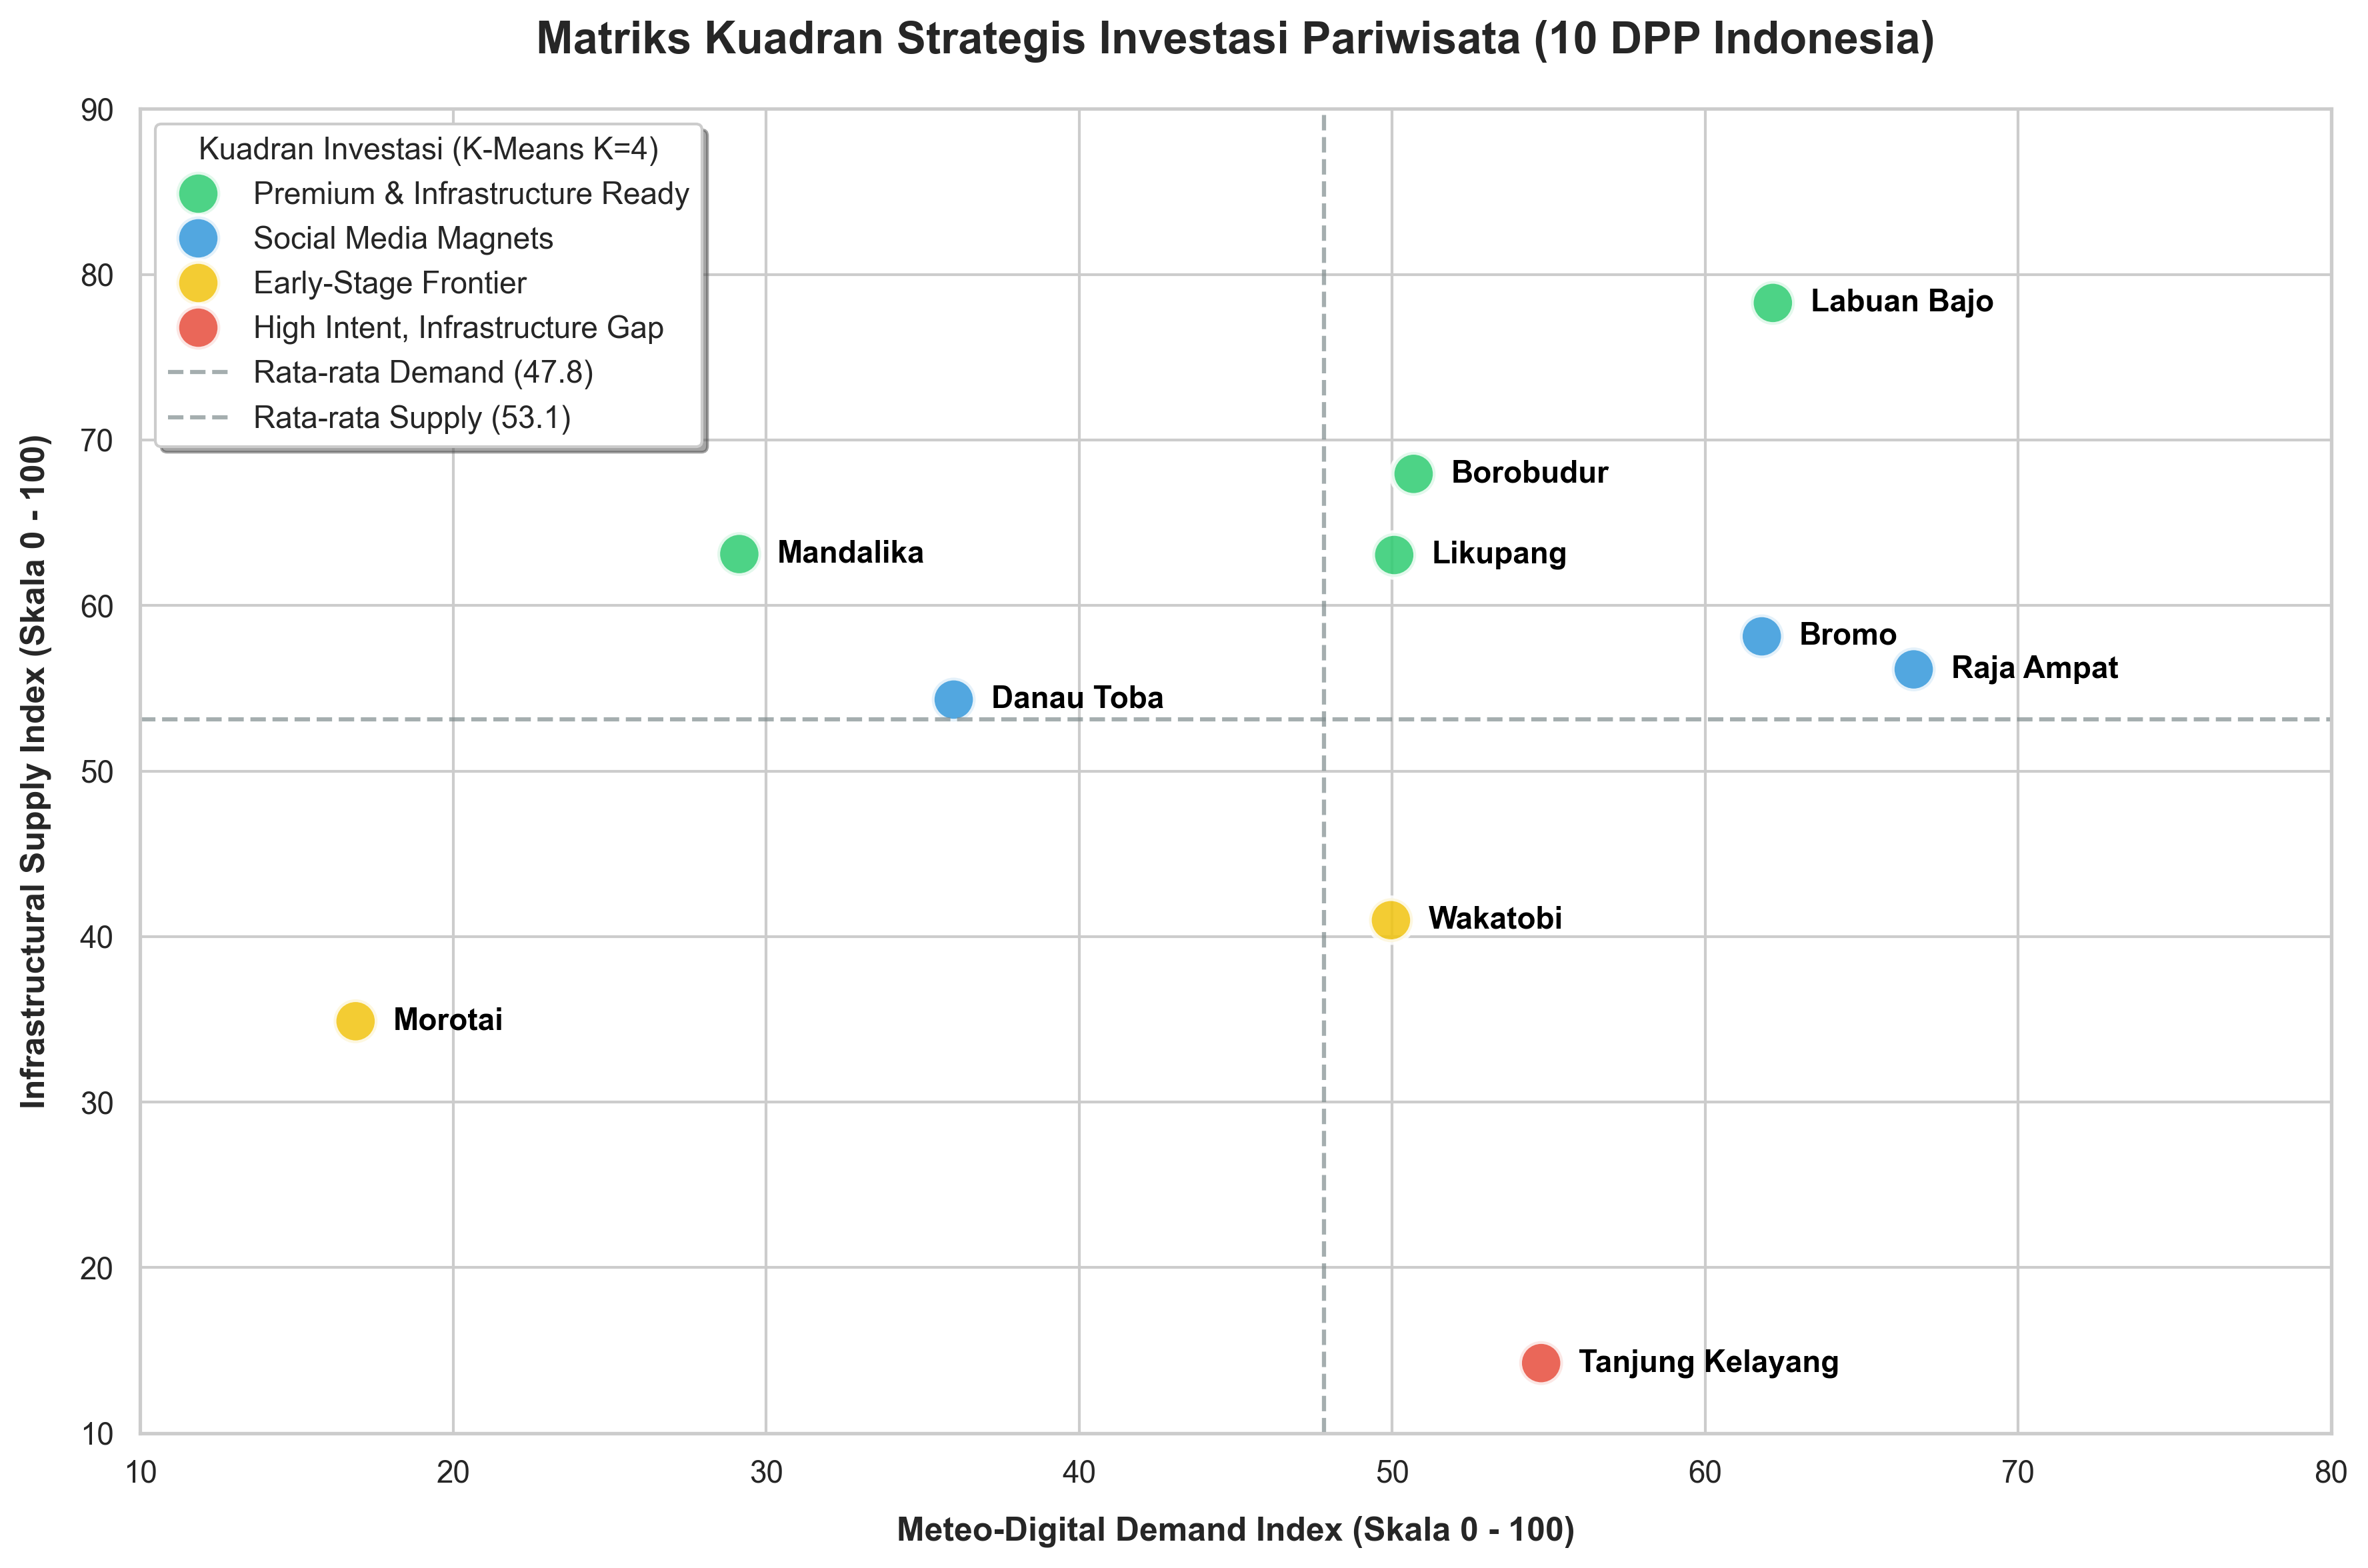


✅ Sukses Besar! Gambar grafik telah disimpan sebagai 'visualisasi_kuadran_investasi.png'.
   Buka folder proyekmu, copy gambar tersebut, dan paste langsung ke Slide 6 PPT kalian!


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating High-Resolution Cluster Visualization...")

# 1. LOAD DATASET FINAL
df_final = pd.read_csv("final_dashboard_dataset.csv")

# 2. SETUP GAYA GRAFIK (Clean & Professional)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8), dpi=300)

# 3. WARNA KHUSUS UNTUK TIAP KLASTER (Gaya Palet Kemenpar)
palette_colors = {
    "High Intent, Infrastructure Gap": "#E74C3C",        # Merah (Butuh Perhatian Akses)
    "Premium & Infrastructure Ready": "#2ECC71",       # Hijau (Sangat Siap)
    "Social Media Magnets": "#3498DB",                 # Biru (Viral Organik)
    "Early-Stage Frontier": "#F1C40F"                  # Kuning (Tahap Rintisan)
}

# 4. DRAW SCATTER PLOT
sns.scatterplot(
    data=df_final,
    x='Demand_Index',
    y='Supply_Index',
    hue='Investment_Quadrant',
    palette=palette_colors,
    s=250, # Ukuran titik diperbesar agar jelas di layar proyektor
    alpha=0.85,
    edgecolor='w',
    linewidth=2
)

# 5. BERI LABEL NAMA DESTINASI PADA SETIAP TITIK (Auto-Positioning)
for i in range(df_final.shape[0]):
    plt.text(
        x=df_final['Demand_Index'][i] + 1.2, # Geser sedikit ke kanan agar tidak menumpuk di titik
        y=df_final['Supply_Index'][i] - 0.5,
        s=df_final['DPP'][i],
        fontdict=dict(color='black', size=11, weight='bold')
    )

# 6. MEMBUAT GARIS SALIB (CROSSHAIR) KUADRAN BERDASARKAN RATA-RATA NASIONAL
# Ini trik visual agar pembagian kuadran terlihat objektif di mata dosen
mean_demand = df_final['Demand_Index'].mean()
mean_supply = df_final['Supply_Index'].mean()

plt.axvline(x=mean_demand, color='#7F8C8D', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Rata-rata Demand ({mean_demand:.1f})')
plt.axhline(y=mean_supply, color='#7F8C8D', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Rata-rata Supply ({mean_supply:.1f})')

# 7. DEKORASI TITLE & AXIS
plt.title("Matriks Kuadran Strategis Investasi Pariwisata (10 DPP Indonesia)", fontsize=16, weight='bold', pad=20)
plt.xlabel("Meteo-Digital Demand Index (Skala 0 - 100)", fontsize=12, weight='bold', labelpad=10)
plt.ylabel("Infrastructural Supply Index (Skala 0 - 100)", fontsize=12, weight='bold', labelpad=10)

# Batasi rentang sumbu agar rapi
plt.xlim(10, 80)
plt.ylim(10, 90)

# Mengatur Posisi Legenda Kotak Klaster
plt.legend(title="Kuadran Investasi (K-Means K=4)", title_fontsize='11', loc='upper left', frameon=True, shadow=True)

# 8. SIMPAN GAMBAR SEBAGAI ASSET PPT
nama_gambar_final = "visualisasi_kuadran_investasi.png"
plt.tight_layout()
plt.savefig(nama_gambar_final, bbox_inches='tight')
plt.show()

print(f"\n✅ Sukses Besar! Gambar grafik telah disimpan sebagai '{nama_gambar_final}'.")
print("   Buka folder proyekmu, copy gambar tersebut, dan paste langsung ke Slide 6 PPT kalian!")

MEMULAI GENERASI PETA PERSEBARAN SPASIAL GEOGRAFIS 10 DPP


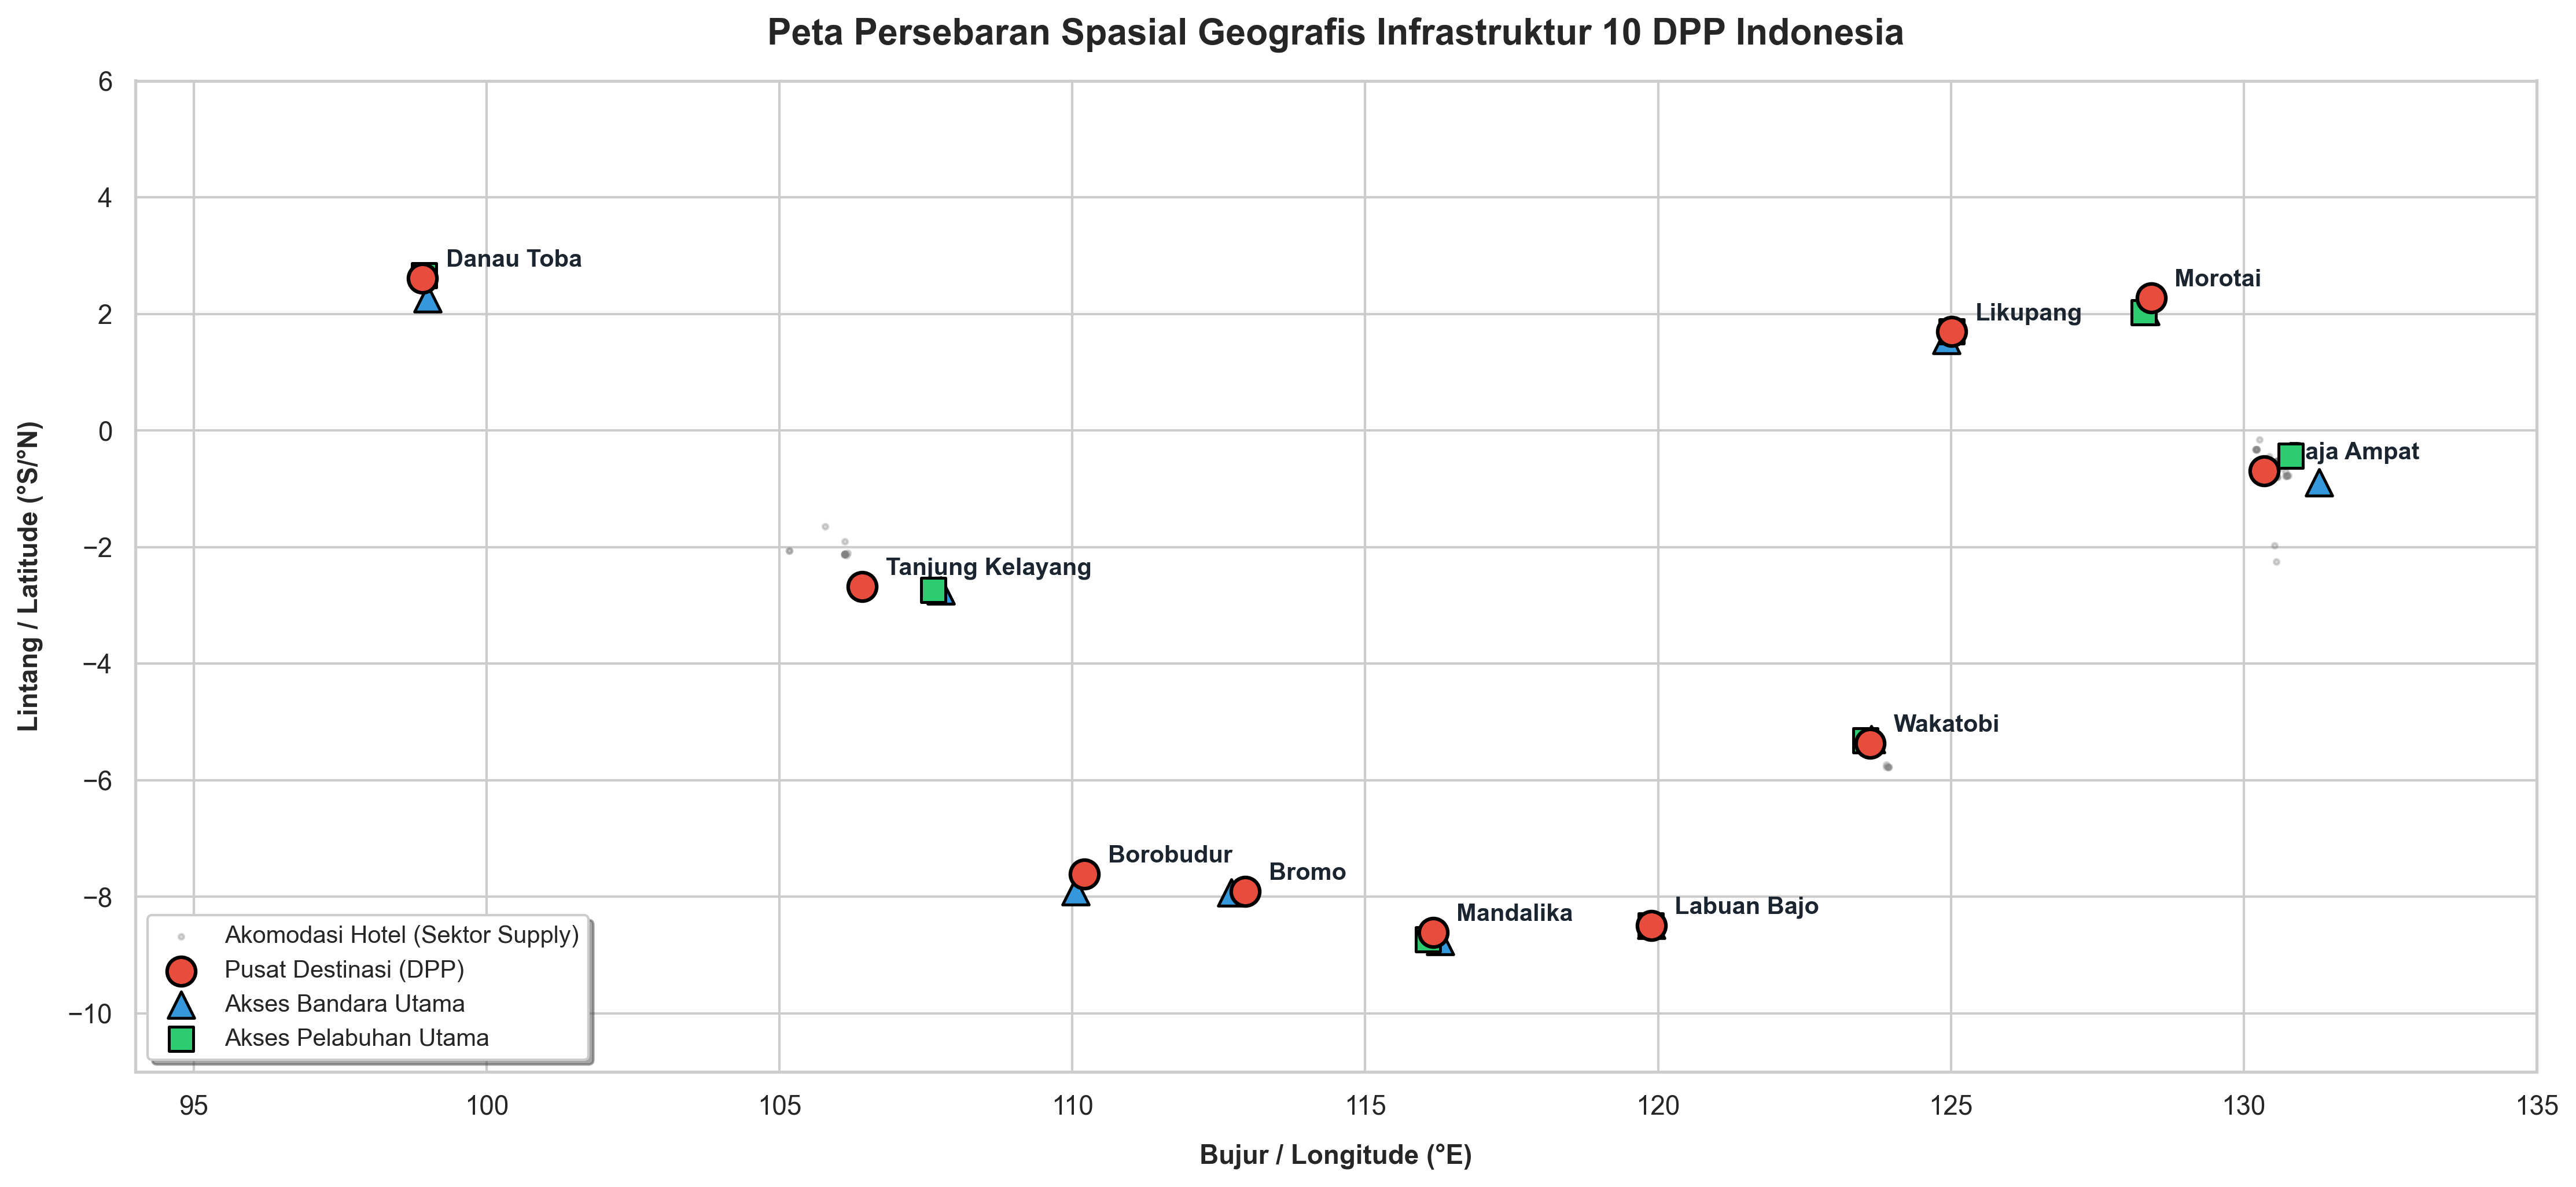


✅ GRAFIK BERHASIL DIREPRODUKSI!
   Aset gambar visualisasi spasial disimpan sebagai 'peta_spasial_geografis_10dpp.png'


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================================")
print("MEMULAI GENERASI PETA PERSEBARAN SPASIAL GEOGRAFIS 10 DPP")
print("==================================================================")

# 1. DEKLARASI DATA KOORDINAT HASIL INTEGRASI INTEGRAL
# Koordinat di bawah ini diekstrak dari master data bandara, 282 pelabuhan, 
# dan nilai rata-rata pusat akomodasi hotel masing-masing wilayah.
dpp_data = {
    'Danau Toba': {
        'lat': 2.610838, 'lon': 98.902308, 
        'air_lat': 2.259730, 'air_lon': 98.991898, 
        'port_lat': 2.6617, 'port_lon': 98.9324
    },
    'Tanjung Kelayang': {
        'lat': -2.674899, 'lon': 106.414906, 
        'air_lat': -2.744109, 'air_lon': 107.754535, 
        'port_lat': -2.7388, 'port_lon': 107.6253
    },
    'Borobudur': {
        'lat': -7.607887, 'lon': 110.204132, 
        'air_lat': -7.905338, 'air_lon': 110.057264, 
        'port_lat': None, 'port_lon': None  # Landlocked (Daratan)
    },
    'Bromo': {
        'lat': -7.905412, 'lon': 112.953770, 
        'air_lat': -7.929099, 'air_lon': 112.714233, 
        'port_lat': None, 'port_lon': None  # Landlocked (Daratan)
    },
    'Mandalika': {
        'lat': -8.612921, 'lon': 116.158080, 
        'air_lat': -8.759962, 'air_lon': 116.278169, 
        'port_lat': -8.7303, 'port_lon': 116.0717
    },
    'Labuan Bajo': {
        'lat': -8.493503, 'lon': 119.884766, 
        'air_lat': -8.480694, 'air_lon': 119.888306, 
        'port_lat': -8.4912, 'port_lon': 119.8745
    },
    'Wakatobi': {
        'lat': -5.368629, 'lon': 123.622600, 
        'air_lat': -5.292123, 'air_lon': 123.636233, 
        'port_lat': -5.3211, 'port_lon': 123.5413
    },
    'Likupang': {
        'lat': 1.694408, 'lon': 125.013761, 
        'air_lat': 1.548591, 'air_lon': 124.926250, 
        'port_lat': 1.694408, 'port_lon': 125.013761
    },
    'Morotai': {
        'lat': 2.275814, 'lon': 128.419514, 
        'air_lat': 2.045990, 'air_lon': 128.324997, 
        'port_lat': 2.0298, 'port_lon': 128.2936
    },
    'Raja Ampat': {
        'lat': -0.691365, 'lon': 130.350935, 
        'air_lat': -0.894000, 'air_lon': 131.287000, 
        'port_lat': -0.432529, 'port_lon': 130.802794
    }
}

# 2. LOAD SEBARAN DATA AKOMODASI HOTEL SEBAGAI LAYER BACKDROP
df_hotels = pd.read_csv("hotel_with_coordinates_baru.csv")

# 3. INSTANSIASI CANVAS DAN SETUP SEABORN
plt.figure(figsize=(15, 7), dpi=300)
sns.set_theme(style="whitegrid")

# LAYER A: Scatter Plot Ribuan Titik Koordinat Hotel (Warna Abu-Abu Transparan)
plt.scatter(
    df_hotels['longitude'], df_hotels['latitude'], 
    color='gray', alpha=0.3, s=5, 
    label='Akomodasi Hotel (Sektor Supply)'
)

# LAYER B: Scatter Plot Titik Pusat Destinasi Pariwisata / DPP (Lingkaran Merah)
dpp_lons = [v['lon'] for v in dpp_data.values()]
dpp_lats = [v['lat'] for v in dpp_data.values()]
plt.scatter(
    dpp_lons, dpp_lats, 
    color='#E74C3C', s=140, marker='o',
    edgecolors='black', linewidths=1.5, zorder=5, 
    label='Pusat Destinasi (DPP)'
)

# LAYER C: Scatter Plot Lokasi Akses Gateway Udara / Bandara (Segitiga Biru)
air_lons = [v['air_lon'] for v in dpp_data.values()]
air_lats = [v['air_lat'] for v in dpp_data.values()]
plt.scatter(
    air_lons, air_lats, 
    color='#3498DB', s=120, marker='^', 
    edgecolors='black', linewidths=1.2, zorder=4, 
    label='Akses Bandara Utama'
)

# LAYER D: Scatter Plot Lokasi Akses Gateway Laut / Pelabuhan (Kotak Hijau)
port_lons = [v['port_lon'] for v in dpp_data.values() if v['port_lon'] is not None]
port_lats = [v['port_lat'] for v in dpp_data.values() if v['port_lat'] is not None]
plt.scatter(
    port_lons, port_lats, 
    color='#2ECC71', s=100, marker='s', 
    edgecolors='black', linewidths=1.2, zorder=4, 
    label='Akses Pelabuhan Utama'
)

# 4. PENEMPATAN TEKS LABEL NAMA DPP SECARA OTOMATIS
for name, coords in dpp_data.items():
    plt.text(
        coords['lon'] + 0.4, coords['lat'] + 0.2, 
        name, fontsize=10, weight='bold', color='#1A252F'
    )

# 5. DEKORASI ESTETIKA PETA INDONESIA
plt.title("Peta Persebaran Spasial Geografis Infrastruktur 10 DPP Indonesia", fontsize=15, weight='bold', pad=15)
plt.xlabel("Bujur / Longitude (°E)", fontsize=11, weight='bold', labelpad=10)
plt.ylabel("Lintang / Latitude (°S/°N)", fontsize=11, weight='bold', labelpad=10)

# Kunci koordinat batas peta wilayah Indonesia agar rapi dan proporsional
plt.xlim(94, 135)
plt.ylim(-11, 6)

# Tampilkan legenda kotak instrumen peta
plt.legend(loc='lower left', frameon=True, shadow=True, facecolor='white', fontsize=10)

# 6. EKSPOR GRAFIK MENJADI ASSET PNG UNTUK PPT TIM
plot_path = "peta_spasial_geografis_10dpp.png"
plt.tight_layout()
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

print("\n✅ GRAFIK BERHASIL DIREPRODUKSI!")
print(f"   Aset gambar visualisasi spasial disimpan sebagai '{plot_path}'")
print("==================================================================")

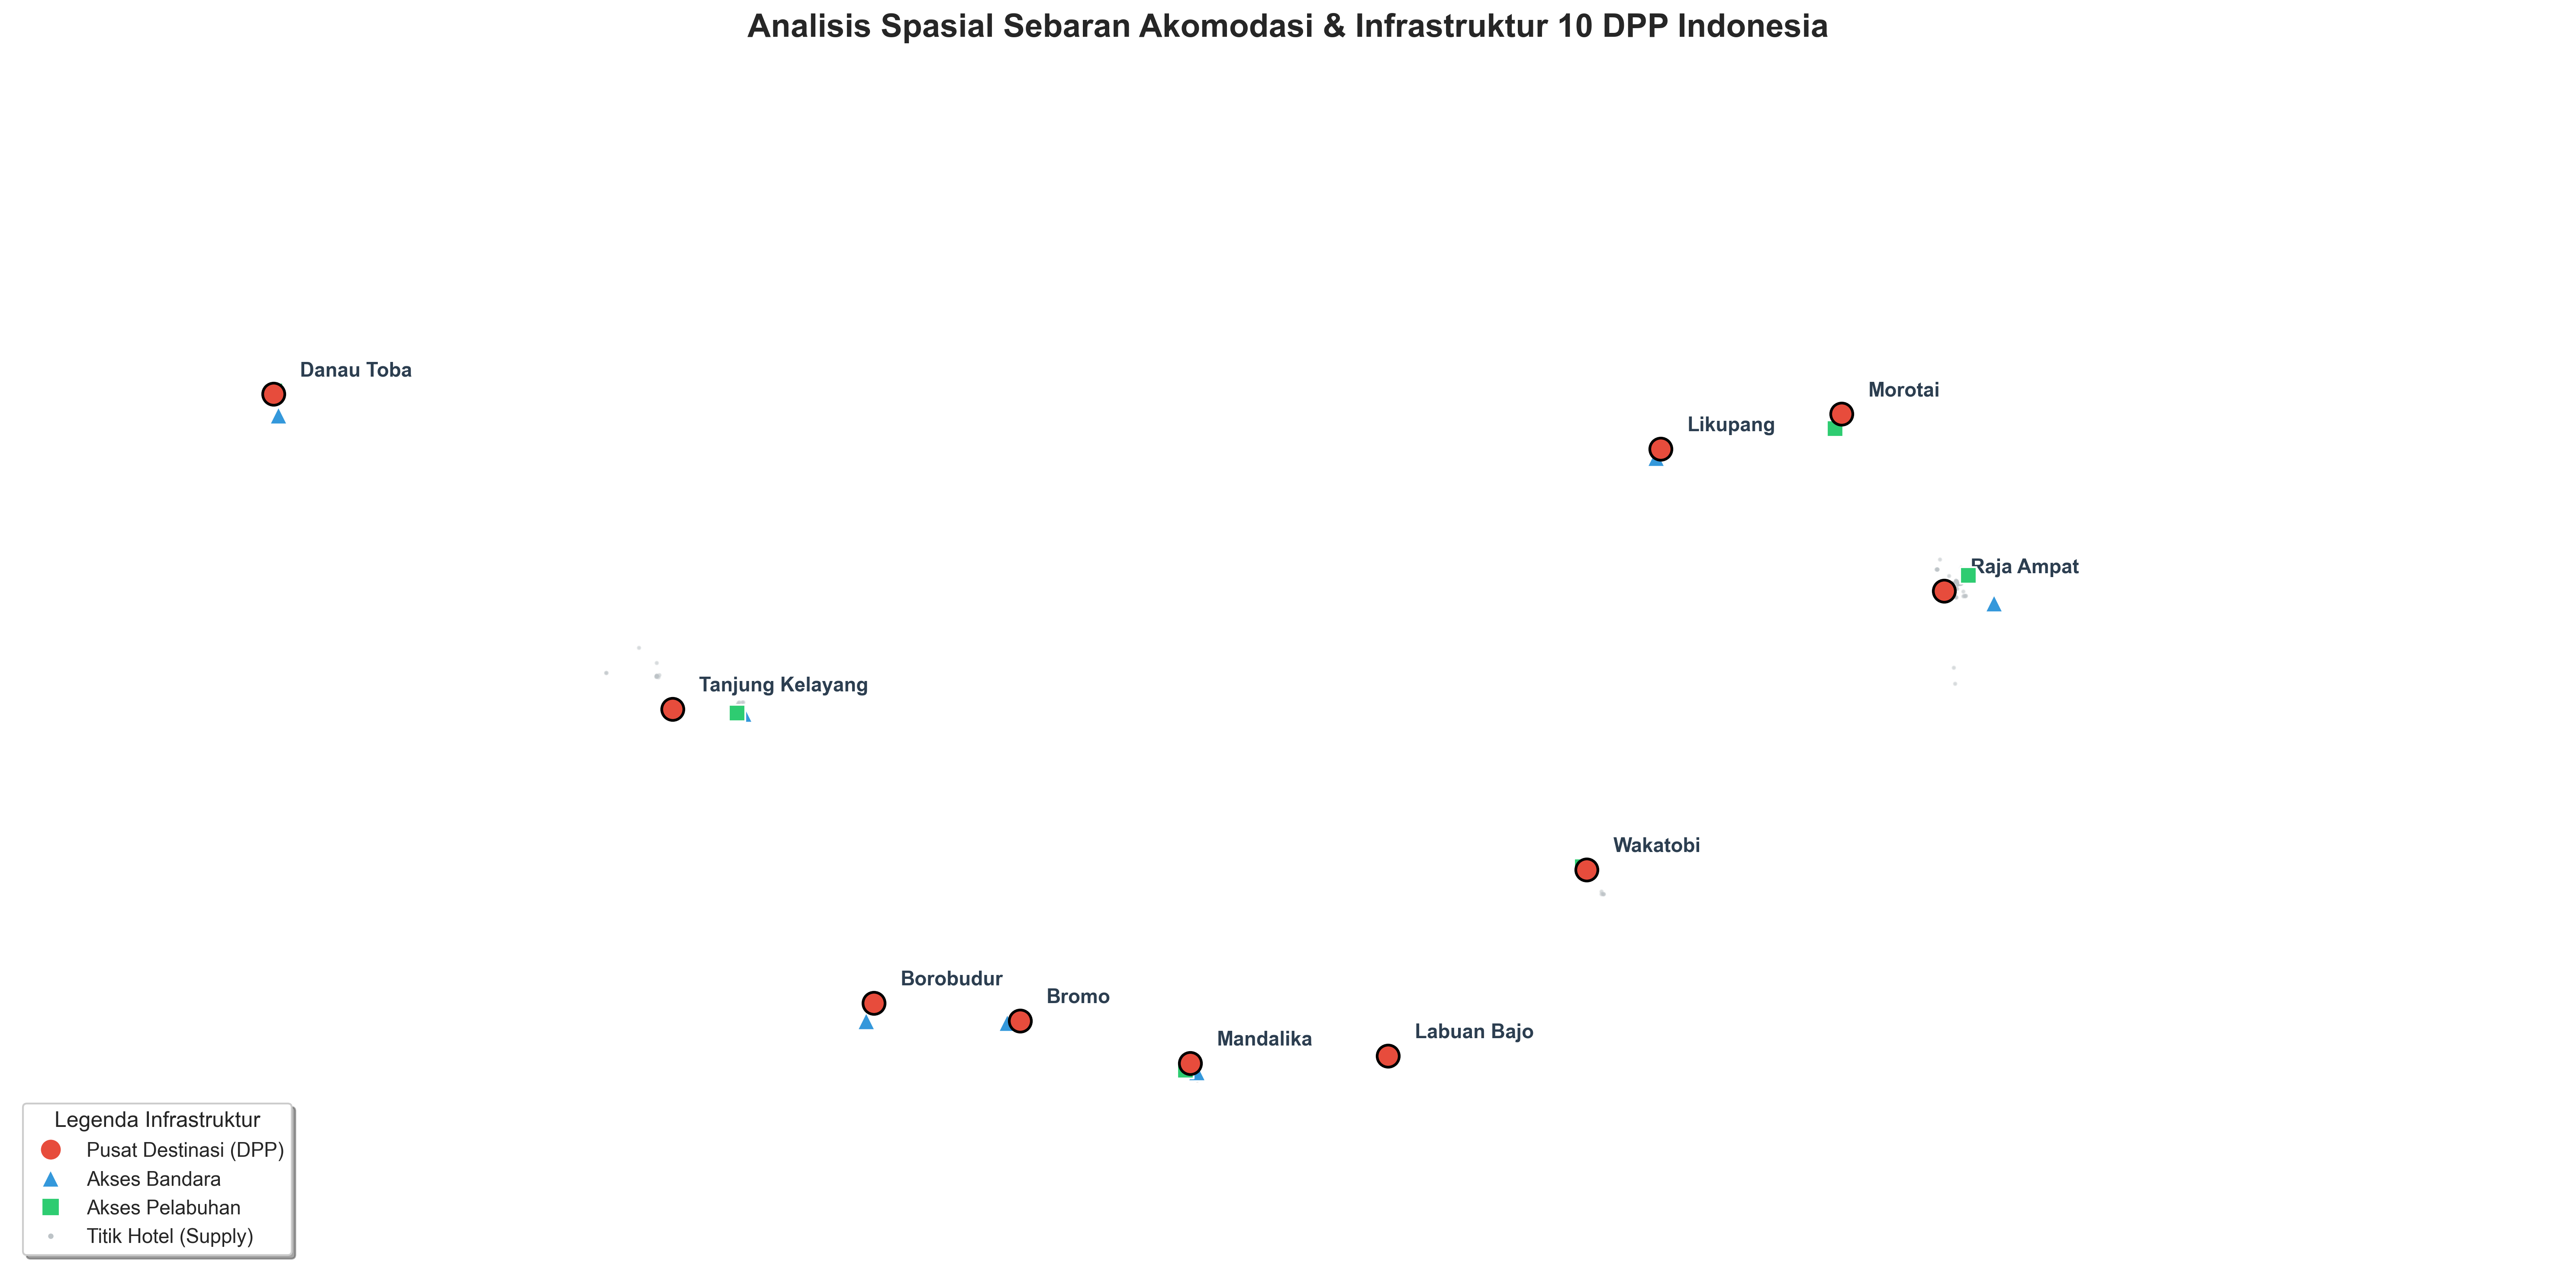

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP DATA (Koordinat Utama)
dpp_coords = {
    'Danau Toba': [2.6108, 98.9023, 2.2597, 98.9918, 2.6617, 98.9324],
    'Tanjung Kelayang': [-2.6749, 106.4149, -2.7441, 107.7545, -2.7388, 107.6253],
    'Borobudur': [-7.6079, 110.2041, -7.9053, 110.0572, None, None],
    'Bromo': [-7.9054, 112.9538, -7.9291, 112.7142, None, None],
    'Mandalika': [-8.6129, 116.1581, -8.7599, 116.2782, -8.7303, 116.0717],
    'Labuan Bajo': [-8.4935, 119.8848, -8.4807, 119.8883, -8.4912, 119.8745],
    'Wakatobi': [-5.3686, 123.6226, -5.2921, 123.6362, -5.3211, 123.5413],
    'Likupang': [1.6944, 125.0138, 1.5486, 124.9263, 1.6944, 125.0138],
    'Morotai': [2.2758, 128.4195, 2.0459, 128.3250, 2.0298, 128.2936],
    'Raja Ampat': [-0.6914, 130.3509, -0.8940, 131.2870, -0.4325, 130.8028]
}

# 2. LOAD DATA HOTEL (PASTIKAN FILE INI ADA)
df_hotels = pd.read_csv("hotel_with_coordinates_baru.csv")

# 3. VISUALISASI
plt.figure(figsize=(20, 10), dpi=300)
sns.set_style("white")

# --- LAYER 1: Titik Persebaran Hotel (THE SUPPLY LANDSCAPE) ---
# Kita gunakan scatter plot dengan ukuran sangat kecil (s=1) agar membentuk bayangan pulau
plt.scatter(df_hotels['longitude'], df_hotels['latitude'], 
            color='#BDC3C7', s=2, alpha=0.4, label='Sebaran Hotel (Supply Index)')

# --- LAYER 2: Aksesibilitas (Bandara & Pelabuhan) ---
for name, c in dpp_coords.items():
    # Bandara (Segitiga Biru)
    plt.scatter(c[3], c[2], color='#3498DB', s=100, marker='^', edgecolors='white', zorder=4)
    # Pelabuhan (Kotak Hijau)
    if c[4] is not None:
        plt.scatter(c[5], c[4], color='#2ECC71', s=80, marker='s', edgecolors='white', zorder=4)

# --- LAYER 3: Pusat DPP (Lingkaran Merah) ---
dpp_lons = [v[1] for v in dpp_coords.values()]
dpp_lats = [v[0] for v in dpp_coords.values()]
plt.scatter(dpp_lons, dpp_lats, color='#E74C3C', s=150, marker='o', 
            edgecolors='black', linewidths=1.5, zorder=5, label='Titik Fokus 10 DPP')

# --- LAYER 4: Label Nama ---
for name, c in dpp_coords.items():
    plt.text(c[1]+0.5, c[0]+0.3, name, fontsize=11, weight='bold', color='#2C3E50')

# Tambahkan Legend Kustom
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Pusat Destinasi (DPP)', markerfacecolor='#E74C3C', markersize=12),
    Line2D([0], [0], marker='^', color='w', label='Akses Bandara', markerfacecolor='#3498DB', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Akses Pelabuhan', markerfacecolor='#2ECC71', markersize=10),
    Line2D([0], [0], marker='.', color='w', label='Titik Hotel (Supply)', markerfacecolor='#BDC3C7', markersize=8),
]
plt.legend(handles=legend_elements, loc='lower left', shadow=True, title="Legenda Infrastruktur")

# Final Touches
plt.title("Analisis Spasial Sebaran Akomodasi & Infrastruktur 10 DPP Indonesia", fontsize=18, weight='bold', pad=20)
plt.xlim(94, 142) # Batas Bujur Indonesia
plt.ylim(-12, 8)   # Batas Lintang Indonesia
plt.axis('off')    # Menghilangkan frame agar lebih estetik seperti peta asli

plt.tight_layout()
plt.savefig("peta_supply_lengkap_indonesia.png", bbox_inches='tight')
plt.show()

In [16]:
import pandas as pd
import folium
from folium.plugins import HeatMap, FeatureGroupSubGroup

print("==================================================================")
print("MEMULAI GENERASI GEOGRAPHIC BASEMAP & HOTEL HEATMAP INDONESIA")
print("==================================================================")

# 1. LOAD DATASET KOORDINAT HOTEL
df_hotels = pd.read_csv("hotel_with_coordinates_baru.csv")
# Bersihkan data koordinat dari nilai kosong jika ada
df_hotels = df_hotels.dropna(subset=['latitude', 'longitude'])

# 2. INISIALISASI PETA REALISTIS INDONESIA
# Menggunakan tiles 'CartoDB positron' untuk memberikan kesan peta premium, bersih, dan fokus pada data
map_indonesia = folium.Map(
    location=[-2.5, 118.0], 
    zoom_start=5, 
    tiles='CartoDB positron'
)

# 3. BUAT LAYER KHUSUS UNTUK HEATMAP HOTEL (THE DENSITY LANDSCAPE)
# Mengubah data ribuan koordinat hotel menjadi pendaran intensitas kepadatan akomodasi
hotel_data = df_hotels[['latitude', 'longitude']].values.tolist()
heatmap_layer = HeatMap(
    data=hotel_data,
    name="Kepadatan Hotel (Supply Heatmap)",
    radius=15,
    blur=10,
    min_opacity=0.4,
    gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'} # Merah menunjukkan area hotel paling padat
)
heatmap_layer.add_to(map_indonesia)

# 4. DATA INFRASTRUKTUR GERBANG UTAMA (GATEWAYS)
dpp_locations = {
    'Danau Toba': [-2.6108, 98.9023, 'DTB (Silangit)', [2.2597, 98.9918], [2.6617, 98.9324], 'Pelabuhan Ajibata'],
    'Tanjung Kelayang': [-2.6749, 106.4149, 'TJQ (Hanandjoeddin)', [-2.7441, 107.7545], [-2.7388, 107.6253], 'Pelabuhan Tanjung Pandan'],
    'Borobudur': [-7.6079, 110.2041, 'YIA (Yogyakarta Int.)', [-7.9053, 110.0572], [None, None], None],
    'Mandalika': [-8.6129, 116.1581, 'LOP (Lombok Int.)', [-8.7599, 116.2781], [-8.7303, 116.0717], 'Pelabuhan Lembar'],
    'Labuan Bajo': [-8.4935, 119.8848, 'LBJ (Komodo Airport)', [-8.4806, 119.8883], [-8.4912, 119.8745], 'Pelabuhan ASDP Labuan Bajo'],
    'Wakatobi': [-5.3686, 123.6226, 'WNI (Matahora)', [-5.2921, 123.6362], [-5.3211, 123.5413], 'Pelabuhan Pangulubelo'],
    'Likupang': [1.6944, 125.0138, 'MDC (Sam Ratulangi)', [1.5485, 124.9262], [1.6944, 125.0138], 'Pelabuhan Munte'],
    'Morotai': [2.2758, 128.4195, 'OTI (Pitu Airport)', [2.0459, 128.3250], [2.0298, 128.2936], 'Pelabuhan Daruba'],
    'Raja Ampat': [-0.6914, 130.3509, 'SOQ (Domine Eduard Osok)', [-0.8940, 131.2870], [-0.4325, 130.8028], 'Pelabuhan Waisai'],
    'Bromo': [-7.9054, 112.9538, 'MLG (Abdul Rachman Saleh)', [-7.9291, 112.7142], [None, None], None]
}

# 5. PLOT MARKER STRATEGIS DI ATAS PETA REALISTIS
for name, coords in dpp_locations.items():
    # A. Marker Pusat Kawasan Wisata / DPP (Pin Merah)
    folium.Marker(
        location=[coords[0], coords[1]],
        popup=f"<div style='font-family: Arial; width: 180px;'><b>Pusat Destinasi:</b> {name}</div>",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(map_indonesia)
    
    # B. Marker Akses Udara / Bandara (Pin Biru + Ikon Pesawat)
    if coords[3][0] is not None:
        folium.Marker(
            location=coords[3],
            popup=f"<div style='font-family: Arial; width: 180px;'><b>Bandara Utama:</b> {coords[2]}</div>",
            icon=folium.Icon(color='blue', icon='plane', prefix='fa')
        ).add_to(map_indonesia)
        
    # C. Marker Akses Laut / Pelabuhan (Pin Hijau + Ikon Jangkar) - Jika Ada
    if coords[4][0] is not None:
        folium.Marker(
            location=coords[4],
            popup=f"<div style='font-family: Arial; width: 180px;'><b>Pelabuhan Utama:</b> {coords[5]}</div>",
            icon=folium.Icon(color='green', icon='anchor', prefix='fa')
        ).add_to(map_indonesia)

# 6. TAMBAHKAN KONTROL LAYER (Bisa dinyalakan/dimatikan secara interaktif)
folium.LayerControl().add_to(map_indonesia)

# 7. SIMPAN SEBAGAI FILE HTML MANDIRI
nama_file_html = "Peta_Akomodasi_Infrastruktur_10DPP.html"
map_indonesia.save(nama_file_html)

print(f"\n✅ INTEGRASI PETA GEOGRAFIS SELESAI!")
print(f"   Silakan buka file '{nama_file_html}' di Google Chrome atau browser laptopmu.")
print("==================================================================")

MEMULAI GENERASI GEOGRAPHIC BASEMAP & HOTEL HEATMAP INDONESIA

✅ INTEGRASI PETA GEOGRAFIS SELESAI!
   Silakan buka file 'Peta_Akomodasi_Infrastruktur_10DPP.html' di Google Chrome atau browser laptopmu.


In [4]:
import pandas as pd
import folium
from folium.plugins import HeatMap

print("==================================================================")
print("MEMULAI GENERASI PETA JARINGAN SPASIAL & LEGENDA PERMANENT 10 DPP")
print("==================================================================")

# 1. LOAD DATASET KOORDINAT HOTEL
df_hotels = pd.read_csv("hotel_with_coordinates_baru.csv")
df_hotels = df_hotels.dropna(subset=['latitude', 'longitude'])

# 2. INISIALISASI PETA BASEMAP
map_indonesia = folium.Map(
    location=[-2.5, 118.0], 
    zoom_start=5, 
    tiles='CartoDB positron'
)

# 3. LAYER HEATMAP HOTEL
hotel_data = df_hotels[['latitude', 'longitude']].values.tolist()
heatmap_layer = HeatMap(
    data=hotel_data,
    name="Kepadatan Hotel (Supply Heatmap)",
    radius=12,
    blur=8,
    min_opacity=0.3,
    gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}
)
heatmap_layer.add_to(map_indonesia)

# 4. DATA INFRASTRUKTUR GERBANG UTAMA (GATEWAYS)
dpp_locations = {
    'Danau Toba': [2.6108, 98.9023, 'DTB (Silangit)', [2.2597, 98.9918], [2.6617, 98.9324], 'Pelabuhan Ajibata'],
    'Tanjung Kelayang': [-2.6749, 106.4149, 'TJQ (Hanandjoeddin)', [-2.7441, 107.7545], [-2.7388, 107.6253], 'Pelabuhan Tanjung Pandan'],
    'Borobudur': [-7.6079, 110.2041, 'YIA (Yogyakarta Int.)', [-7.9053, 110.0572], [None, None], None],
    'Mandalika': [-8.6129, 116.1581, 'LOP (Lombok Int.)', [-8.7599, 116.2781], [-8.7303, 116.0717], 'Pelabuhan Lembar'],
    'Labuan Bajo': [-8.4935, 119.8848, 'LBJ (Komodo Airport)', [-8.4806, 119.8883], [-8.4912, 119.8745], 'Pelabuhan ASDP Labuan Bajo'],
    'Wakatobi': [-5.3686, 123.6226, 'WNI (Matahora)', [-5.2921, 123.6362], [-5.3211, 123.5413], 'Pelabuhan Pangulubelo'],
    'Likupang': [1.6944, 125.0138, 'MDC (Sam Ratulangi)', [1.5485, 124.9262], [1.6944, 125.0138], 'Pelabuhan Munte'],
    'Morotai': [2.2758, 128.4195, 'OTI (Pitu Airport)', [2.0459, 128.3250], [2.0298, 128.2936], 'Pelabuhan Daruba'],
    'Raja Ampat': [-0.6914, 130.3509, 'SOQ (Domine Eduard Osok)', [-0.8940, 131.2870], [-0.4325, 130.8028], 'Pelabuhan Waisai'],
    'Bromo': [-7.9054, 112.9538, 'MLG (Abdul Rachman Saleh)', [-7.9291, 112.7142], [None, None], None]
}

# 5. PLOT MARKER, GARIS JARINGAN, DAN TEXT LABEL PERMANEN
for name, coords in dpp_locations.items():
    dpp_pt = [coords[0], coords[1]]
    air_pt = coords[3]
    port_pt = coords[4]
    
    # --- A. GARIS HUBUNG SPASIAL (Konektivitas Antar Hub) ---
    if air_pt[0] is not None:
        folium.PolyLine(
            locations=[dpp_pt, air_pt], color='#3498DB', 
            weight=2.5, dash_array='6, 6', opacity=0.85
        ).add_to(map_indonesia)
        
    if port_pt[0] is not None:
        folium.PolyLine(
            locations=[dpp_pt, port_pt], color='#2ECC71', 
            weight=2.5, dash_array='6, 6', opacity=0.85
        ).add_to(map_indonesia)

    # --- B. TEXT LABEL PERMANEN (Muncul Otomatis Tanpa Diklik) ---
    folium.Marker(
        location=[coords[0] + 0.2, coords[1] + 0.2], 
        icon=folium.DivIcon(html=f"""<div style="font-family: Arial; font-weight: bold; color: #2C3E50; font-size: 11pt; white-space: nowrap; text-shadow: 1px 1px 2px white;">{name}</div>""")
    ).add_to(map_indonesia)

    # --- C. MARKER PIN DENGAN IKON ---
    folium.Marker(
        location=dpp_pt,
        popup=f"<b>Pusat Destinasi: {name}</b>",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(map_indonesia)
    
    if air_pt[0] is not None:
        folium.Marker(
            location=air_pt,
            popup=f"<b>Bandara:</b> {coords[2]}",
            icon=folium.Icon(color='blue', icon='plane', prefix='fa')
        ).add_to(map_indonesia)
        
    if port_pt[0] is not None:
        folium.Marker(
            location=port_pt,
            popup=f"<b>Pelabuhan:</b> {coords[5]}",
            icon=folium.Icon(color='green', icon='anchor', prefix='fa')
        ).add_to(map_indonesia)

# 6. INJEKSI ELEMEN HTML: LEGENDA KUSTOM MENGAMBANG
html_legend = """
<div style="position: fixed; 
     bottom: 30px; left: 30px; width: 240px; height: 160px; 
     background-color: white; z-index:9999; font-size:11px;
     font-family: Arial, sans-serif; font-weight: bold;
     border:2px solid grey; padding: 12px; border-radius: 8px;
     box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
     <p style="margin-top:0px; margin-bottom:8px; font-size:12px; border-bottom:1px solid #CCC; padding-bottom:4px; color:#2C3E50;">📍 LEGENDA INFRASTRUKTUR</p>
     <div style="margin-bottom:6px;"><i class="fa fa-circle" style="color:red; font-size:12px;"></i> &nbsp; Pusat Fokus 10 DPP</div>
     <div style="margin-bottom:6px;"><i class="fa fa-plane" style="color:blue; font-size:12px;"></i> &nbsp; Akses Udara (Bandara Utama)</div>
     <div style="margin-bottom:6px;"><i class="fa fa-anchor" style="color:green; font-size:12px;"></i> &nbsp; Akses Laut (Pelabuhan Utama)</div>
     <div style="margin-bottom:6px;"><span style="display:inline-block; width:12px; height:8px; background:linear-gradient(to right, blue, lime, red); border-radius:2px;"></span> &nbsp; Kepadatan Akomodasi Hotel</div>
     <div><span style="border-bottom: 2px dashed #7F8C8D; width: 15px; display: inline-block; margin-bottom: 3px;"></span> &nbsp; Garis Hubung Aksesibilitas</div>
</div>
"""
map_indonesia.get_root().html.add_child(folium.Element(html_legend))

# 7. LAYERING & SIMPAN FILE HTML
folium.LayerControl().add_to(map_indonesia)
nama_output = "Peta_Jaringan_Spasial_10DPP.html"
map_indonesia.save(nama_output)

print(f"\n✅ REPRODUKSI SELESAI! Peta jaringan mewah disimpan ke '{nama_output}'")
print("==================================================================")

MEMULAI GENERASI PETA JARINGAN SPASIAL & LEGENDA PERMANENT 10 DPP

✅ REPRODUKSI SELESAI! Peta jaringan mewah disimpan ke 'Peta_Jaringan_Spasial_10DPP.html'


In [1]:
import pandas as pd

# 1. Load Data
df_makan = pd.read_csv('makan_indonesia.csv')
df_atraksi = pd.read_csv('atraksi_indonesia.csv')

# 2. Standarisasi Nama Destinasi
# Mengubah "tempat makan dekat Mandalika" atau "atraksi dekat Mandalika" menjadi "Mandalika"
def clean_destination_name(text):
    text = str(text).lower()
    if 'mandalika' in text: return 'Mandalika'
    if 'labuan bajo' in text: return 'Labuan Bajo'
    if 'likupang' in text: return 'Likupang'
    if 'toba' in text: return 'Danau Toba'
    if 'borobudur' in text: return 'Borobudur'
    if 'belitung' in text: return 'Bangka Belitung'
    if 'wakatobi' in text: return 'Wakatobi'
    if 'bromo' in text: return 'Bromo'
    if 'raja ampat' in text: return 'Raja Ampat'
    if 'morotai' in text: return 'Morotai'
    return text.title()

df_makan['destination_clean'] = df_makan['destination'].apply(clean_destination_name)
df_atraksi['destination_clean'] = df_atraksi['destination'].apply(clean_destination_name)

# 3. Membersihkan Kolom Rating (Mengubah format string "4,7" menjadi float 4.7 jika ada)
for df in [df_makan, df_atraksi]:
    if 'rating' in df.columns:
        df['rating'] = df['rating'].astype(str).str.replace(',', '.')
        df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# 4. Agregasi Data Makan (Restoran)
agg_makan = df_makan.groupby('destination_clean').agg(
    total_restoran=('place_name', 'count'),
    avg_rating_restoran=('rating', 'mean')
).reset_index()

# 5. Agregasi Data Atraksi
agg_atraksi = df_atraksi.groupby('destination_clean').agg(
    total_atraksi=('place_name', 'count'),
    avg_rating_atraksi=('rating', 'mean')
).reset_index()

# 6. Gabungkan Kedua Hasil Agregasi
df_supply_addon = pd.merge(agg_makan, agg_atraksi, on='destination_clean', how='outer')
df_supply_addon.rename(columns={'destination_clean': 'DPP'}, inplace=True)

# Isi nilai kosong (NaN) dengan 0 jika ada wilayah yang tidak memiliki data terpilih
df_supply_addon.fillna(0, inplace=True)

# 7. Tampilkan Hasil Summary
print("--- HASIL AGREGASI DATA SUPPLY BARU KEMENPAR ---")
print(df_supply_addon.to_string(index=False))

# Simpan untuk di-merge dengan matriks utama (Hotel & Flight)
df_supply_addon.to_csv('summary_addon_supply.csv', index=False)

--- HASIL AGREGASI DATA SUPPLY BARU KEMENPAR ---
            DPP  total_restoran  avg_rating_restoran  total_atraksi  avg_rating_atraksi
Bangka Belitung             103             4.455340           99.0            4.438947
      Borobudur              67             4.582090           58.0            4.536842
          Bromo              45             4.593333           22.0            4.677273
     Danau Toba             106             4.472642           43.0            4.490698
    Labuan Bajo             118             4.458120           10.0            4.600000
       Likupang               3             4.750000            4.0            4.450000
      Mandalika              13             4.515385            9.0            4.500000
        Morotai             114             4.586139           12.0            4.500000
     Raja Ampat              68             4.484848            8.0            4.762500
       Wakatobi              67             4.562687            0.0    

In [3]:
import os
import pandas as pd

# 1. Tentukan folder path utama kuliah kamu
folder_path = r"C:\Users\User\Desktop\KULIAH\SEMESTER 6\SDC\kemenpar"

# 2. Membaca ketiga file CSV terkait
print("⏳ Membaca file data master dan revisi...")
df_old_supply = pd.read_csv(os.path.join(folder_path, "master_supply_matrix_final_1.csv"))
df_makan = pd.read_csv(os.path.join(folder_path, "makan_indonesia.csv"))
df_atraksi = pd.read_csv(os.path.join(folder_path, "atraksi_indonesia.csv"))

# 3. Fungsi penyelarasan nama wilayah (Data Alignment) agar sesuai kunci master
def clean_makan_destination(text):
    text = str(text).replace("tempat makan dekat ", "").strip()
    if text == "Bangka Belitung":
        return "Tanjung Kelayang"
    return text

def clean_atraksi_destination(text):
    text = str(text).replace("atraksi dekat ", "").strip()
    if text == "Bangka Belitung":
        return "Tanjung Kelayang"
    return text

# Menerapkan fungsi pembersihan kolom destinasi
df_makan['DPP'] = df_makan['destination'].apply(clean_makan_destination)
df_atraksi['DPP'] = df_atraksi['destination'].apply(clean_atraksi_destination)

# 4. Standardisasi format desimal rating (Mengubah tanda koma ',' menjadi titik '.')
df_makan['rating'] = pd.to_numeric(df_makan['rating'].astype(str).str.replace(',', '.'), errors='coerce')
df_atraksi['rating'] = pd.to_numeric(df_atraksi['rating'].astype(str).str.replace(',', '.'), errors='coerce')

# 5. Proses Agregasi Data Kuliner (Makan) per-DPP
print("📊 Menghitung akumulasi data kuliner...")
makan_agg = df_makan.groupby('DPP').agg(
    Supply_Total_Restaurants=('place_name', 'count'),
    Supply_Avg_Restaurant_Rating=('rating', 'mean')
).reset_index()

# 6. Proses Agregasi Data Objek Wisata (Atraksi) per-DPP
print("📊 Menghitung akumulasi data atraksi...")
atraksi_agg = df_atraksi.groupby('DPP').agg(
    Supply_Total_Attractions=('place_name', 'count'),
    Supply_Avg_Attraction_Rating=('rating', 'mean')
).reset_index()

# 7. Proses Penggabungan (Left Join) Data Baru ke Master Supply Lama
print("🔗 Menggabungkan data ke dalam satu kerangka master...")
df_new_supply = df_old_supply.merge(makan_agg, on='DPP', how='left')
df_new_supply = df_new_supply.merge(atraksi_agg, on='DPP', how='left')

# 8. Penanganan Nilai Kosong (NaN) & Pembulatan Desimal Rating
df_new_supply['Supply_Total_Restaurants'] = df_new_supply['Supply_Total_Restaurants'].fillna(0).astype(int)
df_new_supply['Supply_Avg_Restaurant_Rating'] = df_new_supply['Supply_Avg_Restaurant_Rating'].fillna(0).round(2)
df_new_supply['Supply_Total_Attractions'] = df_new_supply['Supply_Total_Attractions'].fillna(0).astype(int)
df_new_supply['Supply_Avg_Attraction_Rating'] = df_new_supply['Supply_Avg_Attraction_Rating'].fillna(0).round(2)

# 9. Menyimpan hasil matriks supply akhir yang komprehensif
output_file = os.path.join(folder_path, "master_supply_matrix_updated_with_revisions.csv")
df_new_supply.to_csv(output_file, index=False, encoding="utf-8-sig")

print("\n" + "="*50)
print(f"✅ BERHASIL GABUNG! File baru tersimpan di:\n-> {output_file}")
print("="*50)

# Menampilkan cuplikan hasil tabel gabungan di konsol
print(df_new_supply[['DPP', 'Supply_Total_Hotels', 'Supply_Total_Restaurants', 'Supply_Total_Attractions']])

⏳ Membaca file data master dan revisi...
📊 Menghitung akumulasi data kuliner...
📊 Menghitung akumulasi data atraksi...
🔗 Menggabungkan data ke dalam satu kerangka master...

✅ BERHASIL GABUNG! File baru tersimpan di:
-> C:\Users\User\Desktop\KULIAH\SEMESTER 6\SDC\kemenpar\master_supply_matrix_updated_with_revisions.csv
                DPP  Supply_Total_Hotels  Supply_Total_Restaurants  \
0         Borobudur                  207                        67   
1             Bromo                  260                        45   
2        Danau Toba                  449                       106   
3       Labuan Bajo                  238                       118   
4          Likupang                  123                         3   
5         Mandalika                  234                        13   
6           Morotai                   14                       114   
7        Raja Ampat                  415                        68   
8  Tanjung Kelayang                  276         